In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s4e8/sample_submission.csv
/kaggle/input/competitions/playground-series-s4e8/train.csv
/kaggle/input/competitions/playground-series-s4e8/test.csv


In [2]:
df = pd.read_csv('/kaggle/input/competitions/playground-series-s4e8/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/playground-series-s4e8/test.csv')

In [3]:
df.head(2)

,id,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,0,e,8.80,f,s,u,f,a,c,w,...,NaN,NaN,w,NaN,NaN,f,f,NaN,d,a
1,1,p,4.51,x,h,o,f,a,c,n,...,NaN,y,o,NaN,NaN,t,z,NaN,d,w


# 데이터 타입 확인

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3116945 entries, 0 to 3116944
Data columns (total 22 columns):
 #   Column                Dtype  
---  ------                -----  
 0   id                    int64  
 1   class                 object 
 2   cap-diameter          float64
 3   cap-shape             object 
 4   cap-surface           object 
 5   cap-color             object 
 6   does-bruise-or-bleed  object 
 7   gill-attachment       object 
 8   gill-spacing          object 
 9   gill-color            object 
 10  stem-height           float64
 11  stem-width            float64
 12  stem-root             object 
 13  stem-surface          object 
 14  stem-color            object 
 15  veil-type             object 
 16  veil-color            object 
 17  has-ring              object 
 18  ring-type             object 
 19  spore-print-color     object 
 20  habitat               object 
 21  season                object 
dtypes: float64(3), int64(1), object(18)
memory

# 데이터 탐색

In [5]:
display(df['class'].value_counts())
display(df.nunique())
display(df.isnull().sum())

class
p    1705396
e    1411549
Name: count, dtype: int64

id                      3116945
class                         2
cap-diameter               3913
cap-shape                    74
cap-surface                  83
cap-color                    78
does-bruise-or-bleed         26
gill-attachment              78
gill-spacing                 48
gill-color                   63
stem-height                2749
stem-width                 5836
stem-root                    38
stem-surface                 60
stem-color                   59
veil-type                    22
veil-color                   24
has-ring                     23
ring-type                    40
spore-print-color            32
habitat                      52
season                        4
dtype: int64

id                            0
class                         0
cap-diameter                  4
cap-shape                    40
cap-surface              671023
cap-color                    12
does-bruise-or-bleed          8
gill-attachment          523936
gill-spacing            1258435
gill-color                   57
stem-height                   0
stem-width                    0
stem-root               2757023
stem-surface            1980861
stem-color                   38
veil-type               2957493
veil-color              2740947
has-ring                     24
ring-type                128880
spore-print-color       2849682
habitat                      45
season                        0
dtype: int64

In [6]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2077964 entries, 0 to 2077963
Data columns (total 21 columns):
 #   Column                Dtype  
---  ------                -----  
 0   id                    int64  
 1   cap-diameter          float64
 2   cap-shape             object 
 3   cap-surface           object 
 4   cap-color             object 
 5   does-bruise-or-bleed  object 
 6   gill-attachment       object 
 7   gill-spacing          object 
 8   gill-color            object 
 9   stem-height           float64
 10  stem-width            float64
 11  stem-root             object 
 12  stem-surface          object 
 13  stem-color            object 
 14  veil-type             object 
 15  veil-color            object 
 16  has-ring              object 
 17  ring-type             object 
 18  spore-print-color     object 
 19  habitat               object 
 20  season                object 
dtypes: float64(3), int64(1), object(17)
memory usage: 332.9+ MB


In [7]:
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_info = pd.DataFrame({'Missing Values' : missing_values, 'Percentage' : missing_percentage})
print(missing_info)


                      Missing Values  Percentage
id                                 0    0.000000
class                              0    0.000000
cap-diameter                       4    0.000128
cap-shape                         40    0.001283
cap-surface                   671023   21.528227
cap-color                         12    0.000385
does-bruise-or-bleed               8    0.000257
gill-attachment               523936   16.809280
gill-spacing                 1258435   40.373988
gill-color                        57    0.001829
stem-height                        0    0.000000
stem-width                         0    0.000000
stem-root                    2757023   88.452732
stem-surface                 1980861   63.551362
stem-color                        38    0.001219
veil-type                    2957493   94.884350
veil-color                   2740947   87.936970
has-ring                          24    0.000770
ring-type                     128880    4.134818
spore-print-color   

In [8]:
df.nunique()

id                      3116945
class                         2
cap-diameter               3913
cap-shape                    74
cap-surface                  83
cap-color                    78
does-bruise-or-bleed         26
gill-attachment              78
gill-spacing                 48
gill-color                   63
stem-height                2749
stem-width                 5836
stem-root                    38
stem-surface                 60
stem-color                   59
veil-type                    22
veil-color                   24
has-ring                     23
ring-type                    40
spore-print-color            32
habitat                      52
season                        4
dtype: int64

/tmp/ipykernel_16/2069892902.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_values.index, y=missing_values.values, palette='viridis')


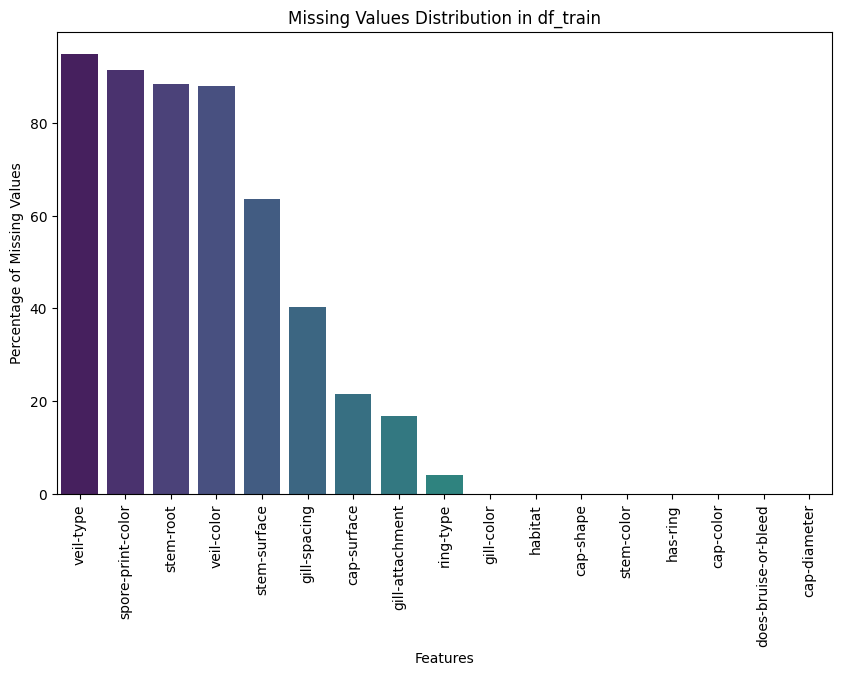

In [9]:
missing_values = df.isnull().mean() * 100
missing_values = missing_values[missing_values >0]
missing_values = missing_values.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=missing_values.index, y=missing_values.values, palette='viridis')
plt.xticks(rotation=90)
plt.xlabel('Features')
plt.ylabel('Percentage of Missing Values')
plt.title('Missing Values Distribution in df_train')
plt.show()

In [10]:
columns_to_drop = ['veil-type', 'veil-color', 'stem-root', 'spore-print-color',]
df = df.drop(columns=columns_to_drop)
test_df = test_df.drop(columns=columns_to_drop)

In [11]:
'''
# For categorical features
categorical_cols = ['cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed',
                    'gill-attachment', 'gill-spacing', 'gill-color',
                    'stem-surface', 'stem-color',
                    'has-ring', 'ring-type', 'habitat']

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)  # Replace NaN with the mode

# For numerical features
numerical_cols = ['cap-diameter']

for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)  # Replace NaN with the median
'''

"\n# For categorical features\ncategorical_cols = ['cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed',\n                    'gill-attachment', 'gill-spacing', 'gill-color',\n                    'stem-surface', 'stem-color',\n                    'has-ring', 'ring-type', 'habitat']\n\nfor col in categorical_cols:\n    df[col].fillna(df[col].mode()[0], inplace=True)  # Replace NaN with the mode\n\n# For numerical features\nnumerical_cols = ['cap-diameter']\n\nfor col in numerical_cols:\n    df[col].fillna(df[col].median(), inplace=True)  # Replace NaN with the median\n"

In [12]:
# Get the counts of each class
class_counts = df['class'].value_counts()

# Calculate the percentage of each class
class_percentage = df['class'].value_counts(normalize=True) * 100

# Display the counts and percentages
class_distribution = pd.DataFrame({'Count': class_counts, 'Percentage': class_percentage})
print(class_distribution)


         Count  Percentage
class                     
p      1705396   54.713702
e      1411549   45.286298


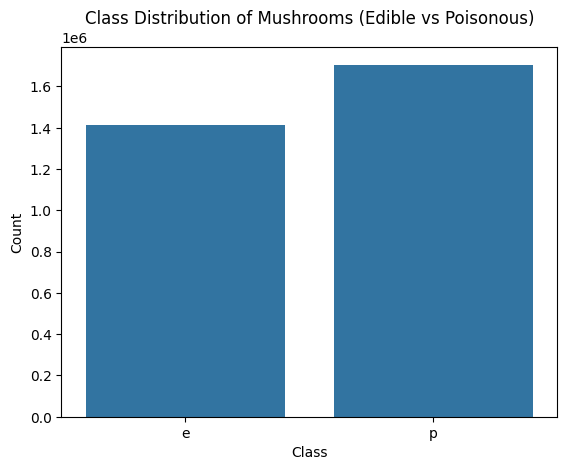

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the class distribution
sns.countplot(x='class', data=df)
plt.title('Class Distribution of Mushrooms (Edible vs Poisonous)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

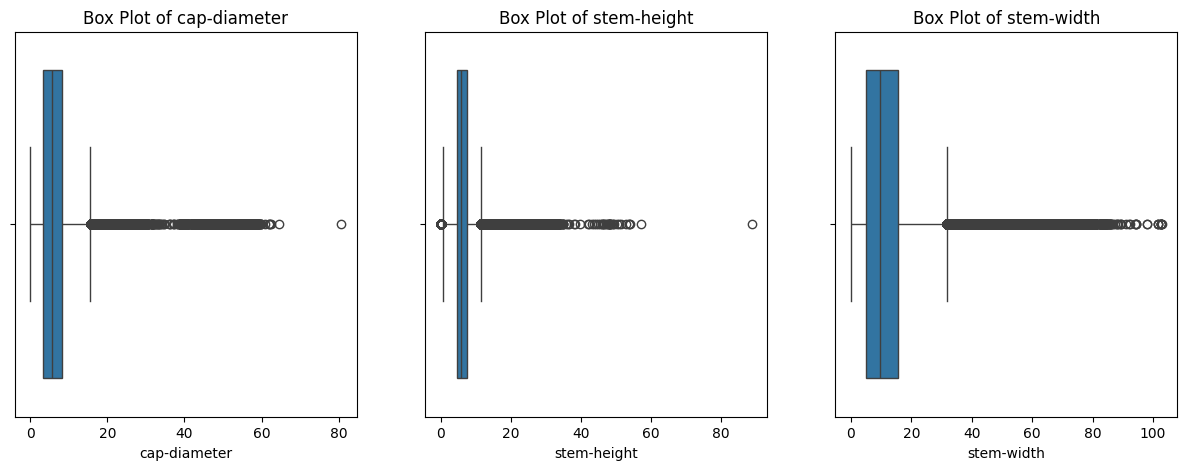

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of numerical columns to check for outliers
numerical_columns = ['cap-diameter', 'stem-height', 'stem-width']

# Plotting box plots for each numerical feature
plt.figure(figsize=(15, 5))
for i, column in enumerate(numerical_columns, 1):
    plt.subplot(1, len(numerical_columns), i)
    sns.boxplot(x=df[column])
    plt.title(f'Box Plot of {column}')
plt.show()


In [15]:
# Function to detect outliers using the IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] < lower_bound) | (data[column] > upper_bound)]

# Apply the function to each numerical column
for column in numerical_columns:
    outliers = detect_outliers_iqr(df, column)
    print(f"Number of outliers in {column}: {outliers.shape[0]}")

Number of outliers in cap-diameter: 76124
Number of outliers in stem-height: 132419
Number of outliers in stem-width: 66481


In [16]:
for column in numerical_columns:
    df = df[~df.index.isin(detect_outliers_iqr(df, column).index)]


In [17]:
cat_cols = [col for col in df.columns if df[col].dtypes == "O"]
df[cat_cols].nunique()

class                    2
cap-shape               69
cap-surface             77
cap-color               73
does-bruise-or-bleed    26
gill-attachment         72
gill-spacing            45
gill-color              62
stem-surface            52
stem-color              56
has-ring                22
ring-type               36
habitat                 50
season                   4
dtype: int64

# 베이스라인 모델

In [18]:
def rare_encoding(df, threshold=0.01):
    for column in df.select_dtypes(include='object').columns:
        if column in df.columns:
            freq = df[column].value_counts(normalize=True)
            rare_classes = freq.index[freq < threshold]
            df[column] = df[column].where(~df[column].isin(rare_classes), 'Rare')
    return df

# Separate the target column
target = df['class']
df_features = df.drop(columns=['class'])

# Apply rare encoding to both datasets
df_features = rare_encoding(df_features)
test_df = rare_encoding(test_df)

# Align columns
common_cols = df_features.columns.intersection(test_df.columns)
df_features = df_features[common_cols]
test_df = test_df[common_cols]

# Reattach the target column
df = pd.concat([df_features, target], axis=1)

# Verify columns
print("df columns:", df.columns)
print("test_df columns:", test_df.columns)

df columns: Index(['id', 'cap-diameter', 'cap-shape', 'cap-surface', 'cap-color',
       'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color',
       'stem-height', 'stem-width', 'stem-surface', 'stem-color', 'has-ring',
       'ring-type', 'habitat', 'season', 'class'],
      dtype='object')
test_df columns: Index(['id', 'cap-diameter', 'cap-shape', 'cap-surface', 'cap-color',
       'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color',
       'stem-height', 'stem-width', 'stem-surface', 'stem-color', 'has-ring',
       'ring-type', 'habitat', 'season'],
      dtype='object')


In [19]:
print(df.shape)
print(test_df.shape)

(2869019, 18)
(2077964, 17)


In [20]:
df[cat_cols].nunique()

class                    2
cap-shape                8
cap-surface             12
cap-color               13
does-bruise-or-bleed     3
gill-attachment          8
gill-spacing             4
gill-color              13
stem-surface             8
stem-color               9
has-ring                 3
ring-type                8
habitat                  6
season                   4
dtype: int64

In [21]:
def encode_categorical(df, target_column=None, max_unique_classes=10):
    for column in df.select_dtypes(include='object').columns:
        if column != target_column:
            unique_classes = df[column].nunique()
            if unique_classes <= max_unique_classes:
                df = pd.get_dummies(df, columns=[column], drop_first=True)
            else:
                le = LabelEncoder()
                df[column] = le.fit_transform(df[column])
    return df

# Separate the target column
target = df['class']
df_features = df.drop(columns=['class'])

# Apply encoding
df_features = encode_categorical(df_features)
test_df = encode_categorical(test_df)

# Ensure both datasets have the same columns
common_cols = df_features.columns.intersection(test_df.columns)
df_features = df_features[common_cols]
test_df = test_df[common_cols]

# Reattach the target column
df = pd.concat([df_features, target], axis=1)

# Verify columns
print("df columns:", df.columns)
print("test_df columns:", test_df.columns)

df columns: Index(['id', 'cap-diameter', 'cap-surface', 'cap-color', 'gill-color',
       'stem-height', 'stem-width', 'cap-shape_b', 'cap-shape_c',
       'cap-shape_f', 'cap-shape_o', 'cap-shape_p', 'cap-shape_s',
       'cap-shape_x', 'does-bruise-or-bleed_f', 'does-bruise-or-bleed_t',
       'gill-attachment_a', 'gill-attachment_d', 'gill-attachment_e',
       'gill-attachment_f', 'gill-attachment_p', 'gill-attachment_s',
       'gill-attachment_x', 'gill-spacing_c', 'gill-spacing_d',
       'gill-spacing_f', 'stem-surface_g', 'stem-surface_h', 'stem-surface_i',
       'stem-surface_k', 'stem-surface_s', 'stem-surface_t', 'stem-surface_y',
       'stem-color_e', 'stem-color_g', 'stem-color_n', 'stem-color_o',
       'stem-color_p', 'stem-color_u', 'stem-color_w', 'stem-color_y',
       'has-ring_f', 'has-ring_t', 'ring-type_e', 'ring-type_f', 'ring-type_g',
       'ring-type_l', 'ring-type_p', 'ring-type_r', 'ring-type_z', 'habitat_d',
       'habitat_g', 'habitat_h', 'habitat_l', 

In [22]:
print(df.shape)
print(test_df.shape)

(2869019, 59)
(2077964, 58)


In [23]:
df['class'] = df['class'].map({'e': 0, 'p': 1})

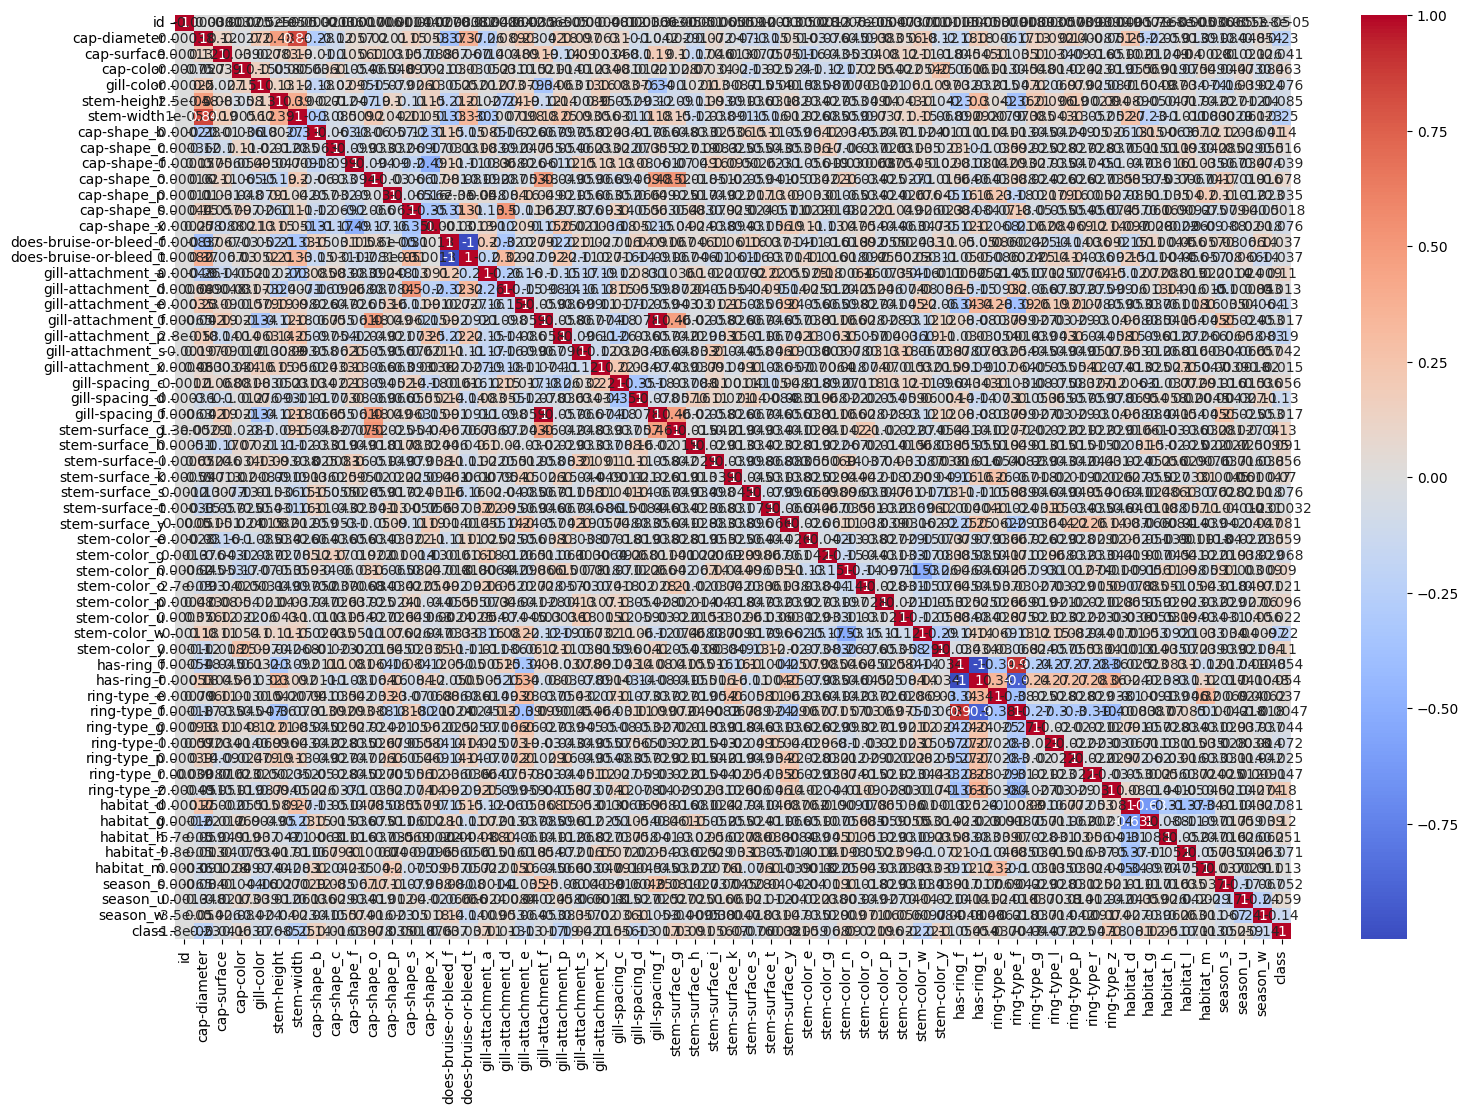

In [24]:
plt.figure(figsize=(18, 12))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [25]:
import pandas as pd
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

# Assuming X is a pandas DataFrame and y is the target column in the DataFrame

# Separate features and target
X = df.drop('class', axis=1)
y = df['class']

# Impute missing values with the median for numerical features
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Convert imputed data back to a DataFrame
X_imputed_df = pd.DataFrame(X_imputed, columns=X.columns)

# Perform feature selection
selector = SelectKBest(score_func=chi2, k=10)
X_new = selector.fit_transform(X_imputed_df, y)

# Get selected feature names
selected_features = X.columns[selector.get_support()]
print("Selected features:", selected_features)

Selected features: Index(['cap-diameter', 'stem-width', 'cap-shape_b', 'gill-attachment_e',
       'gill-attachment_p', 'gill-spacing_d', 'stem-surface_g', 'stem-color_w',
       'ring-type_z', 'season_w'],
      dtype='object')


In [26]:
'''Selected= ['class', 'cap-diameter', 'stem-width', 'cap-shape_b', 'gill-attachment_a',
       'gill-attachment_e', 'gill-attachment_p', 'stem-surface_g',
       'stem-color_w', 'ring-type_z', 'season_w']
testSelected= ['cap-diameter', 'stem-width', 'cap-shape_b', 'gill-attachment_a',
       'gill-attachment_e', 'gill-attachment_p', 'stem-surface_g',
       'stem-color_w', 'ring-type_z', 'season_w']
df_SELECTED = df[Selected]
df.shape
test_df_SELECTED = test_df[testSelected]'''

"Selected= ['class', 'cap-diameter', 'stem-width', 'cap-shape_b', 'gill-attachment_a',\n       'gill-attachment_e', 'gill-attachment_p', 'stem-surface_g',\n       'stem-color_w', 'ring-type_z', 'season_w']\ntestSelected= ['cap-diameter', 'stem-width', 'cap-shape_b', 'gill-attachment_a',\n       'gill-attachment_e', 'gill-attachment_p', 'stem-surface_g',\n       'stem-color_w', 'ring-type_z', 'season_w']\ndf_SELECTED = df[Selected]\ndf.shape\ntest_df_SELECTED = test_df[testSelected]"

In [27]:
# Separate features and target
X_train = df.drop('class', axis=1)
y_train = df['class']

# Test data (no target)
X_test = test_df.copy()

In [28]:
train_columns = set(df.columns)
test_columns = set(test_df.columns)

# Find columns in train_df but not in test_df
train_only_columns = train_columns - test_columns

# Find columns in test_df but not in train_df
test_only_columns = test_columns - train_columns

# Print the columns that are different
print("Columns in train_df but not in test_df:")
print(train_only_columns)

print("\nColumns in test_df but not in train_df:")
print(test_only_columns)

Columns in train_df but not in test_df:
{'class'}

Columns in test_df but not in train_df:
set()


In [29]:
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

In [30]:
parameters={'n_estimators': 297, 'max_depth': 19, 'learning_rate': 0.028333382496137323, 'subsample': 0.9947997083813288,
            'colsample_bytree': 0.5336230391923533,
            'gamma': 0.16126940334635828}

In [31]:
xgb_model = xgb.XGBClassifier(**parameters)
xgb_model.fit(X_train_split, y_train_split)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5336230391923533, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=0.16126940334635828, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.028333382496137323,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=19, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=297, n_jobs=None,
              num_parallel_tree=None, ...)

In [32]:
test_predictions = xgb_model.predict(X_test)

# Evaluate the model on training data using train_test_split 
#X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)
y_val_pred = xgb_model.predict(X_val_split)

# Evaluate the model on the validation set
accuracy = accuracy_score(y_val_split, y_val_pred)
print(f'Accuracy: {accuracy:.4f}')
print('Classification Report:')
print(classification_report(y_val_split, y_val_pred))
print('Confusion Matrix:')
print(confusion_matrix(y_val_split, y_val_pred))

Accuracy: 0.9926
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    262807
           1       0.99      0.99      0.99    310997

    accuracy                           0.99    573804
   macro avg       0.99      0.99      0.99    573804
weighted avg       0.99      0.99      0.99    573804

Confusion Matrix:
[[261056   1751]
 [  2473 308524]]


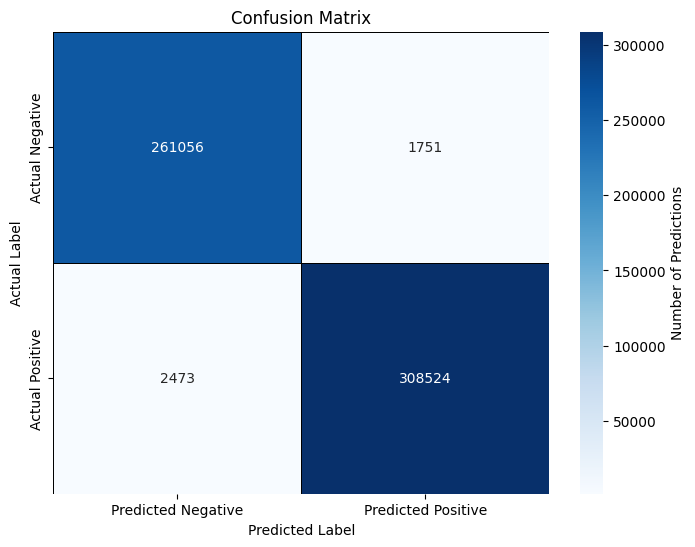

In [33]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Define the confusion matrix
conf_matrix = confusion_matrix(y_val_split, y_val_pred)

# Convert the confusion matrix to a DataFrame for better visualization with seaborn
conf_matrix_df = pd.DataFrame(conf_matrix, 
                              index=['Actual Negative', 'Actual Positive'], 
                              columns=['Predicted Negative', 'Predicted Positive'])

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_df, annot=True, fmt='d', cmap='Blues', 
            linewidths=0.5, linecolor='black', 
            cbar_kws={'label': 'Number of Predictions'})
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [34]:
''' ######## Still working in that #######
# Separate features and target
X_train = df.drop('class', axis=1)
y_train = df['class']

# Test data (no target)
X_test = test_df.copy()

# Split the data into training and validation sets
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

# Define the hyperparameters for LGBMClassifier (adjusted for LGBM)
parameters = {'n_estimators': 1869, 'max_depth': 32, 'learning_rate': 0.010217690029650325,
              'subsample': 0.847713364798533, 'colsample_bytree': 0.9861945128452118,
              'min_child_weight': 3.584741970207093, 'reg_alpha': 0.5182335134716664,
              'reg_lambda': 0.10566374380137711}

# Initialize the LGBMClassifier
lgbm_model = lgb.LGBMClassifier(**parameters)

# Train the model
lgbm_model.fit(X_train_split, y_train_split)

# Predict on the test data
test_predictions = lgbm_model.predict(X_test)

# Evaluate the model on the validation set
y_val_pred = lgbm_model.predict(X_val_split)

# Calculate accuracy and MCC
accuracy = accuracy_score(y_val_split, y_val_pred)
mcc = matthews_corrcoef(y_val_split, y_val_pred)

print(f'Validation Accuracy: {accuracy:.4f}')
#print(f'Validation MCC: {mcc:.4f}')
print('Classification Report:')
print(classification_report(y_val_split, y_val_pred))
print('Confusion Matrix:')
print(confusion_matrix(y_val_split, y_val_pred))
'''

" ######## Still working in that #######\n# Separate features and target\nX_train = df.drop('class', axis=1)\ny_train = df['class']\n\n# Test data (no target)\nX_test = test_df.copy()\n\n# Split the data into training and validation sets\nX_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)\n\n# Define the hyperparameters for LGBMClassifier (adjusted for LGBM)\nparameters = {'n_estimators': 1869, 'max_depth': 32, 'learning_rate': 0.010217690029650325,\n              'subsample': 0.847713364798533, 'colsample_bytree': 0.9861945128452118,\n              'min_child_weight': 3.584741970207093, 'reg_alpha': 0.5182335134716664,\n              'reg_lambda': 0.10566374380137711}\n\n# Initialize the LGBMClassifier\nlgbm_model = lgb.LGBMClassifier(**parameters)\n\n# Train the model\nlgbm_model.fit(X_train_split, y_train_split)\n\n# Predict on the test data\ntest_predictions = lgbm_model.predict(X_test)\n\n# 

In [35]:
'''
import optuna
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, matthews_corrcoef, classification_report, confusion_matrix
from optuna.samplers import TPESampler

# Separate features and target
X_train = df.drop('class', axis=1)
y_train = df['class']

# Split the data into training and validation sets
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

# Scale the features
scaler = StandardScaler()
X_train_split_scaled = scaler.fit_transform(X_train_split)
X_val_split_scaled = scaler.transform(X_val_split)
X_test_scaled = scaler.transform(X_test)  

# Define the objective function for Optuna
def objective(trial):
    # Define the hyperparameters to tune
    param = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'use_label_encoder': False,
        'random_state': 42,
        'n_estimators': trial.suggest_int('n_estimators', 200, 300),
        'max_depth': trial.suggest_int('max_depth', 12, 20),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 0.3)
    }

    # Initialize and train the XGBoost model
    model = xgb.XGBClassifier(**param)
    model.fit(X_train_split_scaled, y_train_split)

    # Predict on the validation set
    y_val_pred = model.predict(X_val_split_scaled)

    # Calculate the MCC
    mcc = matthews_corrcoef(y_val_split, y_val_pred)

    return mcc

# Create a study object and optimize the objective function
study = optuna.create_study(direction='maximize', sampler=TPESampler())
study.optimize(objective, n_trials=50)

# Get the best hyperparameters
best_params = study.best_params

# Train the best model on the entire training data
best_model = xgb.XGBClassifier(**best_params, objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)
best_model.fit(X_train_split_scaled, y_train_split)

# Predict on the validation set with the best model
y_val_pred = best_model.predict(X)
'''

"\nimport optuna\nimport xgboost as xgb\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.metrics import accuracy_score, matthews_corrcoef, classification_report, confusion_matrix\nfrom optuna.samplers import TPESampler\n\n# Separate features and target\nX_train = df.drop('class', axis=1)\ny_train = df['class']\n\n# Split the data into training and validation sets\nX_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)\n\n# Scale the features\nscaler = StandardScaler()\nX_train_split_scaled = scaler.fit_transform(X_train_split)\nX_val_split_scaled = scaler.transform(X_val_split)\nX_test_scaled = scaler.transform(X_test)  \n\n# Define the objective function for Optuna\ndef objective(trial):\n    # Define the hyperparameters to tune\n    param = {\n        'objective': 'binary:logistic',\n        'eval_metric': 'logloss',\n        'use

In [36]:
'''import optuna
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, matthews_corrcoef, classification_report, confusion_matrix
from optuna.samplers import TPESampler

# Separate features and target
X_train = df.drop('class', axis=1)
y_train = df['class']

# Split the data into training and validation sets
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

# Scale the features
scaler = StandardScaler()
X_train_split_scaled = scaler.fit_transform(X_train_split)
X_val_split_scaled = scaler.transform(X_val_split)
X_test_scaled = scaler.transform(X_test)  # Scale the test data as well

# Define the objective function for Optuna
def objective(trial):
    # Define the hyperparameters to tune
    param = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'boosting_type': 'gbdt',
        'random_state': 42,
        'n_estimators': trial.suggest_int('n_estimators', 200, 2000),
        'max_depth': trial.suggest_int('max_depth', 9, 35),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'subsample': trial.suggest_float('subsample', 0.8, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.8, 1.0),
        'min_child_weight': trial.suggest_float('min_child_weight', 0.001, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0)
    }

    # Initialize and train the LGBM model
    model = lgb.LGBMClassifier(**param)
    model.fit(X_train_split_scaled, y_train_split)

    # Predict on the validation set
    y_val_pred = model.predict(X_val_split_scaled)

    # Calculate the MCC
    mcc = matthews_corrcoef(y_val_split, y_val_pred)

    return mcc

# Create a study object and optimize the objective function
study = optuna.create_study(direction='maximize', sampler=TPESampler())
study.optimize(objective, n_trials=50)

# Get the best hyperparameters
best_params = study.best_params

# Train the best model on the entire training data
best_model = lgb.LGBMClassifier(**best_params, objective='binary', metric='binary_logloss', boosting_type='gbdt', random_state=42)
best_model.fit(X_train_split_scaled, y_train_split)

# Predict on the validation set with the best model
y_val_pred = best_model.predict(X_val_split_scaled)

# Evaluate the best model
accuracy = accuracy_score(y_val_split, y_val_pred)
mcc = matthews_corrcoef(y_val_split, y_val_pred)

print(f'Best Hyperparameters: {best_params}')
print(f'Validation Accuracy: {accuracy:.4f}')
print(f'Validation MCC: {mcc:.4f}')
print('Classification Report:')
print(classification_report(y_val_split, y_val_pred))
print('Confusion Matrix:')
print(confusion_matrix(y_val_split, y_val_pred))

# Predict on the test data
test_predictions = best_model.predict(X_test_scaled)'''

"import optuna\nimport lightgbm as lgb\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.metrics import accuracy_score, matthews_corrcoef, classification_report, confusion_matrix\nfrom optuna.samplers import TPESampler\n\n# Separate features and target\nX_train = df.drop('class', axis=1)\ny_train = df['class']\n\n# Split the data into training and validation sets\nX_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)\n\n# Scale the features\nscaler = StandardScaler()\nX_train_split_scaled = scaler.fit_transform(X_train_split)\nX_val_split_scaled = scaler.transform(X_val_split)\nX_test_scaled = scaler.transform(X_test)  # Scale the test data as well\n\n# Define the objective function for Optuna\ndef objective(trial):\n    # Define the hyperparameters to tune\n    param = {\n        'objective': 'binary',\n        'metric': 'binary_lo